## Import packages

In [26]:
from sentence_transformers import SentenceTransformer

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## Import Model

In [27]:
embedd_model = "all-MiniLM-L6-v2"
model = SentenceTransformer(embedd_model)


In [28]:
label_encoder = LabelEncoder()
svm_model = SVC(kernel = "linear", probability = True)

## Split data

In [29]:
df = pd.read_csv("intent_dataset.csv") # data genereated by ChatGPR
df.head()

,text,intent
0,hey there how's it going,greeting
1,hello can you help me,greeting
2,hi i have a question,greeting
3,hey are you the car assistant,greeting
4,hi there i just joined,greeting


In [30]:
texts = df['text']
labels = df['intent']

In [31]:
text_embedd = model.encode(texts)
label_encode = label_encoder.fit_transform(labels)

In [32]:
text_train, text_test, label_train, label_test = train_test_split(
    text_embedd,
    label_encode,
    test_size = 0.25,
    shuffle = True, # Data doesn't shuffle all are in contigues way one label after other label starts
    random_state = 42
)

In [33]:
text_test

array([[ 5.91466576e-02, -1.63498195e-03,  5.36164641e-02, ...,
        -4.47428273e-03, -4.19755131e-02,  3.89900990e-02],
       [ 1.13160172e-02, -8.22068658e-04, -1.47672892e-02, ...,
        -4.04815972e-02,  5.17183132e-02,  1.08284905e-04],
       [-7.57189170e-02,  1.32956598e-02,  6.10837992e-03, ...,
         4.74152640e-02, -4.05264087e-02, -3.71875502e-02],
       ...,
       [-3.57209332e-02,  8.53505656e-02, -4.50747423e-02, ...,
        -3.88438515e-02,  1.75414663e-02, -1.00888051e-02],
       [ 2.86362171e-02,  5.29609844e-02,  3.20167630e-03, ...,
        -1.16991848e-01, -2.78948732e-02,  3.69016156e-02],
       [-6.10140823e-02, -5.43309711e-02, -1.93649647e-03, ...,
         1.74959358e-02,  2.66388133e-02,  5.61396917e-03]],
      shape=(729, 384), dtype=float32)

In [34]:
label_test

array([14,  2,  4,  0, 12,  9,  3, 14,  8,  1, 14,  1, 11, 11,  8,  6, 14,
       10, 11,  6,  5, 14,  1,  8,  5,  6,  1,  1,  8, 11, 11, 11,  1,  1,
       14,  8, 14,  5,  3,  4, 13,  4, 11, 13,  3,  7,  9, 11,  8,  5,  7,
        6,  9, 11,  5, 14, 11,  0,  2, 13,  9, 11,  3,  0,  0, 11,  3,  5,
        2,  0, 11, 11,  7, 14, 13, 12,  6, 13,  6, 10,  6, 10,  1, 12, 10,
       10, 11, 13,  7,  0, 10, 10, 11, 12, 13,  0, 14,  0,  3,  4,  9,  1,
       11,  1,  0, 10,  4, 11,  3,  6, 12,  5,  9,  3, 12,  7,  3, 10,  8,
        9,  8, 11,  9, 11, 14,  4,  2,  1, 11, 13, 11, 10,  5, 13,  4, 10,
       10,  9,  3, 13,  1, 12,  3, 10,  8,  2, 12,  0,  0, 11,  6,  5,  4,
        2,  0, 14,  3,  3, 11,  3, 11,  3,  1,  7,  1,  4,  7,  4,  9,  0,
        5,  6, 12,  2,  7, 11,  0, 11,  9, 12, 13,  8,  0, 12, 12,  1,  9,
        8, 11,  6,  9,  6,  9, 11,  9,  6,  4, 11, 11,  8,  9, 14,  3,  0,
        3,  5,  4, 10, 13, 11,  2, 11,  8,  1, 12,  9,  8,  7, 12,  7,  0,
        3,  6,  6,  7, 12

## Train/Test the model

In [35]:
svm_model.fit(
    text_train,
    label_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
y_pred_test = svm_model.predict(text_test)
y_pred_train = svm_model.predict(text_train)
print(f"Accuracy_for_testing_data: {accuracy_score(label_test, y_pred_test):.2%}")
print(f"Accuracy_for_training_data: {accuracy_score(label_train, y_pred_train):.2%}")

Accuracy_for_testing_data: 97.12%
Accuracy_for_training_data: 99.08%


In [37]:
print(classification_report(label_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        49
           1       0.98      0.96      0.97        55
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        47
           4       1.00      1.00      1.00        46
           5       0.90      0.97      0.94        39
           6       0.98      0.98      0.98        45
           7       0.98      0.98      0.98        42
           8       0.98      0.94      0.96        49
           9       0.98      1.00      0.99        51
          10       0.94      0.98      0.96        49
          11       0.97      0.94      0.95       111
          12       1.00      0.97      0.99        38
          13       0.97      1.00      0.99        35
          14       0.98      1.00      0.99        40

    accuracy                           0.97       729
   macro avg       0.97      0.98      0.97       729
weighted avg       0.97   

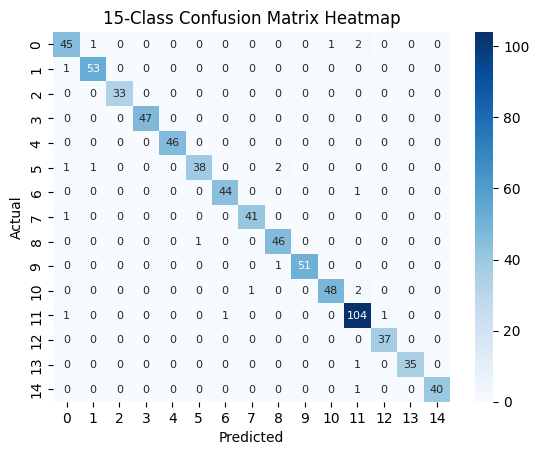

In [38]:
cm = confusion_matrix(y_pred_test, label_test)
sns.heatmap(
    cm, 
    annot=True,
    fmt='d',
    cmap = 'Blues',
    annot_kws={"size": 8}
    )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('15-Class Confusion Matrix Heatmap')
plt.show()

In [39]:
joblib.dump({
    "model": svm_model,
    "label_encoder": label_encoder
}, "intent_detect_v1.pkl")


['intent_detect_v1.pkl']

In [40]:
df['intent'].unique()

array(['greeting', 'goodbye', 'search_car', 'ask_details',
       'filter_location', 'sort_price', 'sort_year', 'sort_mileage',
       'compare_cars', 'check_availability', 'book_test_drive',
       'contact_seller', 'negotiate_price', 'financing_options',
       'fallback_help'], dtype=object)